# **WSINDy for ODEs & PDEs: Examples**

This notebook illustrates the merged Weak SINDy class (`wsindy_ode_pde.py`), which handles both ODE and PDE systems through the `equation_type` attribute (`'ode'` or `'pde'`).

---

The examples are:
- the $(1+1)$-dimensional Kuramoto Sivashinsky equation (`'pde'`)
- the logistic equation (`'ode'`)
- the Lotka-Volterra equations (`'ode'`)
- the Lorenz '63 equations (`'ode'`)

Each recovered model is verified against the known ground truth, and robustness is confirmed over several noise realizations.

In [1]:
import sys
sys.path.append('..')

import torch
import numpy as np
import matplotlib.pyplot as plt

from scipy.integrate import solve_ivp
from IPython.display import display,Math

from wsindy_ode_pde import *

torch.set_default_dtype(torch.float64)
torch.manual_seed(0)

In [3]:
# Plot settings
import matplotlib

plt.rcParams['mathtext.fontset'] = 'cm'
plt.rcParams['font.family'] = 'STIXGeneral'
plt.rcParams['font.size'] = 12
#plt.rcParams['figure.dpi'] = 100
plt.rcParams['figure.dpi'] = 200

matplotlib.rc('xtick', labelsize=10, direction='out')
matplotlib.rc('ytick', labelsize=10, direction='out')

Utilities and helpers...

In [5]:
def to_torch_solution(sol):
  return [torch.tensor(ui, dtype=torch.float64) for ui in sol.y]

def add_noise_to_states(states, noise):
  if noise == 0:
    return states
  return [add_noise(ui, noise) for ui in states]

def plot_states(t, states, names, title):
  plt.figure(figsize=(7,3))
  for ui,name in zip(states,names):
    plt.plot(t, ui, label='$' + name + '(t)$')
  plt.xlabel('$t$')
  plt.title(title)
  plt.grid(True, alpha=0.3)
  plt.legend(loc='upper left')
  plt.show()

def fit_wsindy_ode(Ui, V, local_names, t, beta, m, p, s, Lambda, rescale=True, verbosity=False):
  alpha = [[1], [0]]
  model = WSINDy(Ui, alpha, beta, t, V=V, names=local_names, m=m, p=p, s=s,
                 verbosity=verbosity, rescale=rescale, equation_type='ode')
  [G,powers,derivs,rhs_names] = model.create_default_library()
  model.build_lhs(local_names[0] + model.derivative_names[0])
  model.set_library(G, powers, derivs, rhs_names)
  _ = model.MSTLS(Lambda=Lambda)
  return model

def fit_wsindy_system(states, t, names, beta, m, p, s, Lambda=1e-3, rescale=True, verbosity=False):
  models = []
  odes = []

  for i,Ui in enumerate(states):
    aux_inds = [j for j in range(len(states)) if j != i]
    V = [states[j] for j in aux_inds]
    local_names = [names[i]] + [names[j] for j in aux_inds]

    model = fit_wsindy_ode(Ui, V, local_names, t, beta, m, p, s, Lambda, rescale, verbosity)
    display(Math(r'\Theta_{' + names[i] + r'}=' + r'\{' + r', \, '.join(model.rhs_names) + r'\}'))
    model.print_report()

    models.append(model)
    odes.append(symbolic_eqn(model.lhs_name, model.rhs_names, model.coeffs))

  for ode in odes:
    display(Math(ode))
  return models,odes

def check_recovery(model, truth, tol=0.1):
  got = {name: c for name,c in zip(model.rhs_names, model.coeffs.tolist()) if c != 0}
  assert set(got) == set(truth), f'Support mismatch: {got}'
  for name,c in truth.items():
    assert abs(got[name] - c)/abs(c) < tol, f'{name}: {got[name]:.4f} vs {c}'
  print('Verified: ' + ', '.join(f'{name} = {got[name]:.4f} (true {c:g})' for name,c in truth.items()))

## **KURAMOTO SIVASHINSKY**

In this example, we use data from a numerical solution of the $(1+1)$-dimensional Kuramoto Sivashinsky equation: $$\begin{align*}
u_t = -\frac{1}{2}\left(u^2\right)_{x} - u_{xx} - u_{xxxx},
\quad \text{for} \quad
\begin{cases}
x \in [0, \, 32\pi],
\\
\, t \in [0, \, 150],
\end{cases}
\end{align*}$$ using periodic boundary conditions. See the `KS.txt` file (1.3 MB) located in the `Datasets` folder.

In [6]:
noise = 0.2

Imported tensor with shape (256, 301)


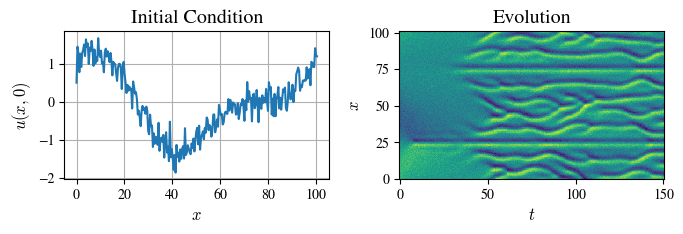

In [5]:
data_path = '../Datasets/KS.txt'

# Read in CSV data
U0 = torch.tensor(np.loadtxt(data_path, delimiter=','))
torch.manual_seed(0)
U = U0 if noise == 0 else add_noise(U0, noise)

# Reshape to Nx x ... x Nt tensor
[L, T] = [32*np.pi, 150]
[Nx, Nt] = [256, 301]
U = U.view(Nx, -1)
print(f"Imported tensor with shape {U.numpy().shape}")

# Space and time
x = torch.linspace(0, L, Nx)
t = torch.linspace(0, T, Nt)

# Plot the data
fig,ax = plt.subplots(1,2,figsize=(7,2.5))

ax[0].plot(x, U[:,0])
ax[0].set_title('Initial Condition')
ax[0].set_xlabel('$x$')
ax[0].set_ylabel('$u(x,0)$')
ax[0].grid(True)

X,T = torch.meshgrid(x, t, indexing='ij')
ax[1].pcolormesh(T, X, U)
ax[1].set_title('Evolution')
ax[1].set_xlabel('$t$')
ax[1].set_ylabel('$x$')

fig.tight_layout()
plt.show()
del fig,ax,X,L,T

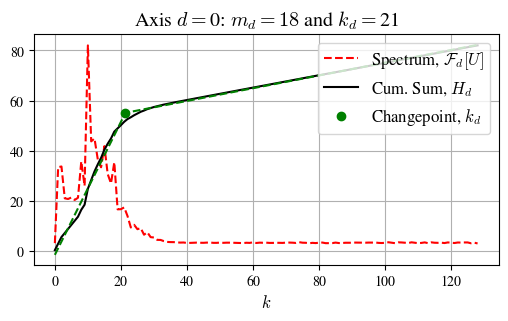

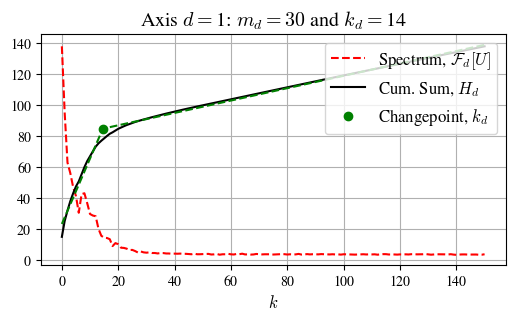

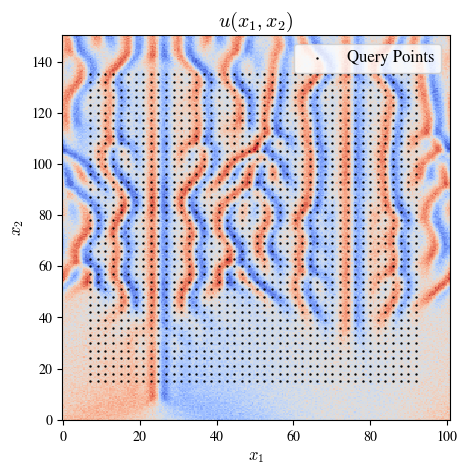

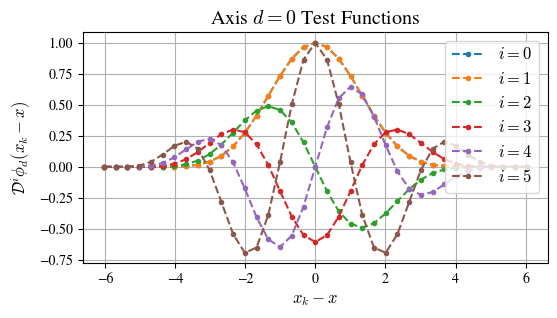

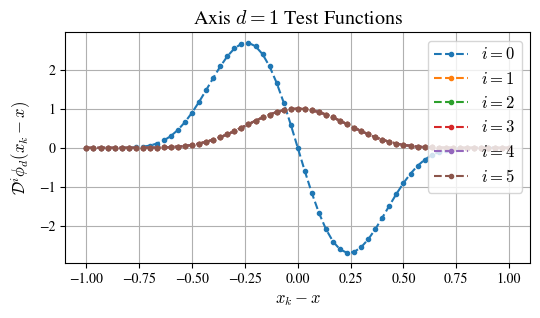

In [6]:
X = [x,t]

# Derivatives for test fcns
alpha = [[0,1],
         [0,0],
         [1,0],
         [2,0],
         [3,0],
         [4,0]]

# Powers for homogeneous fcns
beta = [[0],
        [1],
        [2]]

model = WSINDy(U, alpha, beta, X, equation_type='pde')

In [7]:
# Create standard library terms
[G,powers,derivs,rhs_names] = model.create_default_library()

# Add a funky non-homogeneous term, e.g., D^i cos(u)
i = 1
kernel = [model.axes[d][i,:] for d in range(U.ndim)]
yxyt = np.prod(model.yx + [model.yt])
cos_term = compute_weak_trig(U, kernel, model.spacing, freq=1., phase=0., yxyt=yxyt)

G.append(cos_term[model.conv_mask])
powers.append([0])
derivs.append(i)
rhs_names.append(r'\cos(u)' + model.derivative_names[i])

del i, yxyt, kernel, cos_term


  0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 5/5 [00:00<00:00, 344.49it/s]

In [8]:
# Display the library in LaTeX
lib_string = r'\Theta=' + r'\{' + r', \, '.join(rhs_names) + r'\}'
display(Math(lib_string))

<IPython.core.display.Math object>

In [9]:
# Set lhs
lhs_name = 'u' + model.derivative_names[0]
model.build_lhs(lhs_name)

# Set library
model.set_library(G, powers, derivs, rhs_names)

# Find sparse weights
w = model.MSTLS()
model.print_report()

HYPER-PARAMETERS
m = [18, 30]
p = [11, 9]
s = [5, 6]
[yx, yt] = [0.849, 0.067]
yu = 0.740
Aux. scales = []

LIBRARY
Num. query points = 1804
Num. terms = 12
cond(G) = 6.256e+01

RESULTS
PDE: u_{t} = - 0.49(u^2)_{x} - 0.99(u)_{xx} - 1.00(u)_{xxxx}
Nonzero terms = 3
Rel. L2 error = 0.144
R^2 = 0.979
Lambda = 1.326e-02
Loss = 0.263


In [10]:
pde = symbolic_pde(model.lhs_name, model.rhs_names, model.coeffs)
display(Math(pde))

ks_truth = {'(u^2)_{x}': -0.5, '(u)_{xx}': -1.0, '(u)_{xxxx}': -1.0}
check_recovery(model, ks_truth, tol=0.05)

<IPython.core.display.Math object>

Verified: (u^2)_{x} = -0.4929 (true -0.5), (u)_{xx} = -0.9944 (true -1), (u)_{xxxx} = -0.9966 (true -1)


Robustness check: the same recovery should hold across independent noise realizations.

In [11]:
for seed in range(3):
  torch.manual_seed(seed)
  U_n = add_noise(U0, noise).view(Nx, -1)
  model_n = WSINDy(U_n, alpha, beta, X, m=model.m, p=model.p, s=model.s,
                   verbosity=False, equation_type='pde')
  [G_n,powers_n,derivs_n,rhs_names_n] = model_n.create_default_library()
  model_n.build_lhs('u' + model_n.derivative_names[0])
  model_n.set_library(G_n, powers_n, derivs_n, rhs_names_n)
  _ = model_n.MSTLS()
  check_recovery(model_n, ks_truth, tol=0.05)

del U, U0, model, model_n, X, x, t, alpha, beta, noise
del G, powers, derivs, rhs_names, G_n, powers_n, derivs_n, rhs_names_n
del lhs_name, lib_string, w, pde, Nx, Nt


  0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 5/5 [00:00<00:00, 372.03it/s]

Verified: (u^2)_{x} = -0.4929 (true -0.5), (u)_{xx} = -0.9944 (true -1), (u)_{xxxx} = -0.9966 (true -1)



  0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 5/5 [00:00<00:00, 431.36it/s]

Verified: (u^2)_{x} = -0.4914 (true -0.5), (u)_{xx} = -0.9870 (true -1), (u)_{xxxx} = -0.9912 (true -1)



  0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 5/5 [00:00<00:00, 341.77it/s]

Verified: (u^2)_{x} = -0.4957 (true -0.5), (u)_{xx} = -0.9919 (true -1), (u)_{xxxx} = -1.0015 (true -1)


## **LOGISTIC EQUATION**

This example is
\begin{align*}
  \dot u = r u\left(1 - \frac{u}{K}\right),
  \quad \text{with} \quad
  \begin{cases}
    r = 1.5,
    \\
    K=2.
  \end{cases}
\end{align*}

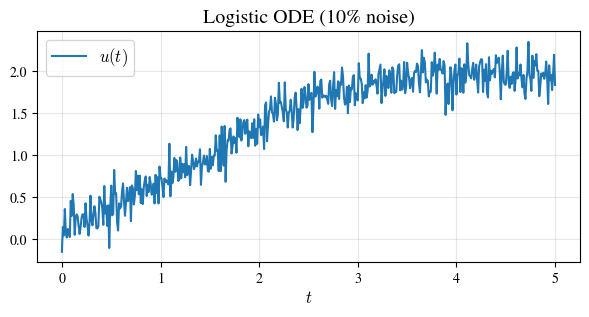

In [12]:
r = 1.5
K = 2.0
t_np = np.linspace(0, 5, 501)

def logistic_rhs(t, u):
  return r*u*(1 - u/K)

sol = solve_ivp(logistic_rhs, (t_np[0], t_np[-1]), [0.2], t_eval=t_np, rtol=1e-12, atol=1e-12, method='DOP853')

noise = 0.10
t = torch.tensor(t_np, dtype=torch.float64)
logistic_clean = to_torch_solution(sol)
torch.manual_seed(0)
[u] = add_noise_to_states(logistic_clean, noise)

plot_states(t_np, [u], ['u'], f'Logistic ODE ({noise*100:.0f}% noise)')

In [13]:
beta = [[0], [1], [2]]

[models, odes] = fit_wsindy_system([u], t, ['u'], beta, m=[16], p=[8], s=[5], Lambda=1e-1)
check_recovery(models[0], {'(u)': 1.5, '(u^2)': -0.75}, tol=0.1)


  0%|          | 0/1 [00:00<?, ?it/s]


100%|██████████| 1/1 [00:00<00:00, 1559.22it/s]

<IPython.core.display.Math object>

HYPER-PARAMETERS
m = [16]
p = [8]
s = [5]
yt = 6.250
yu = 0.741
Aux. scales = []

LIBRARY
Num. query points = 94
Num. terms = 3
cond(G) = 3.275e+01

RESULTS
ODE: u_{t} = + 1.50(u) - 0.75(u^2)
Nonzero terms = 2
Rel. L2 error = 0.845
R^2 = 0.118
Lambda = 1.000e-01
Loss = 0.674


<IPython.core.display.Math object>

Verified: (u) = 1.4986 (true 1.5), (u^2) = -0.7458 (true -0.75)


## **LOTKA-VOLTERRA**

This pup is:
\begin{align*}
  \begin{cases}
    \dot{x} = ax - bxy,\\
    \dot{y} = -cy + dxy,
  \end{cases}
  \quad \text{with} \quad
  \begin{cases}
    a = 1.5,
    \\
    b = 1,
    \\
    c = 3,
    \\
    d = 1.
  \end{cases}
\end{align*}

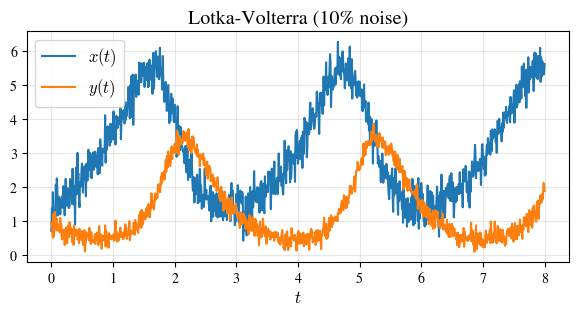

In [14]:
a = 1.5
b = 1.0
c = 3.0
d = 1.0
t_np = np.linspace(0, 8, 1001)

def lotka_volterra_rhs(t, z):
  x,y = z
  return [a*x - b*x*y,
          -c*y + d*x*y]

sol = solve_ivp(lotka_volterra_rhs, (t_np[0], t_np[-1]), [1.5, 1.0], t_eval=t_np,
                rtol=1e-12, atol=1e-12, method='DOP853')

noise = 0.10
t = torch.tensor(t_np, dtype=torch.float64)
lv_clean = to_torch_solution(sol)
torch.manual_seed(0)
[x,y] = add_noise_to_states(lv_clean, noise)

plot_states(t_np, [x,y], ['x','y'], f'Lotka-Volterra ({noise*100:.0f}% noise)')

In [15]:
beta = [[0,0],
        [1,0],
        [0,1],
        [2,0],
        [1,1],
        [0,2]]

[models, odes] = fit_wsindy_system([x,y], t, ['x','y'], beta, m=[20], p=[10], s=[5], Lambda=1e-1)
check_recovery(models[0], {'(x)': 1.5, '(x y)': -1.0}, tol=0.1)
check_recovery(models[1], {'(y)': -3.0, '(y x)': 1.0}, tol=0.1)


  0%|          | 0/1 [00:00<?, ?it/s]


100%|██████████| 1/1 [00:00<00:00, 1210.13it/s]

<IPython.core.display.Math object>

HYPER-PARAMETERS
m = [20]
p = [10]
s = [5]
yt = 6.250
yu = 0.473
Aux. scales = [0.608]

LIBRARY
Num. query points = 193
Num. terms = 6
cond(G) = 1.546e+02

RESULTS
ODE: x_{t} = + 1.50(x) - 0.99(x y)
Nonzero terms = 2
Rel. L2 error = 0.496
R^2 = 0.749
Lambda = 1.000e-01
Loss = 0.358



  0%|          | 0/1 [00:00<?, ?it/s]

...

<IPython.core.display.Math object>

HYPER-PARAMETERS
m = [20]
p = [10]
s = [5]
yt = 6.250
yu = 0.608
Aux. scales = [0.473]

LIBRARY
Num. query points = 193
Num. terms = 6
cond(G) = 1.546e+02

RESULTS
ODE: y_{t} = - 3.03(y) + 1.00(y x)
Nonzero terms = 2
Rel. L2 error = 0.340
R^2 = 0.885
Lambda = 1.000e-01
Loss = 0.357


<IPython.core.display.Math object>

<IPython.core.display.Math object>

Verified: (x) = 1.4957 (true 1.5), (x y) = -0.9897 (true -1)
Verified: (y) = -3.0273 (true -3), (y x) = 1.0011 (true 1)


## **LORENZ '63**

The all-time classic:
\begin{align*}
  \begin{cases}
    \dot{x} = \sigma(y-x),\\
    \dot{y} = x(\rho-z)-y,\\
    \dot{z} = xy-\beta z,
  \end{cases}
  \quad \text{with} \quad
  \begin{cases}
    \sigma = 10,
    \\
    \rho = 28,
    \\
    \beta = 8/3.
  \end{cases}
\end{align*}

For each state equation below, the library is ordered with the left-hand-side state first and the remaining states as auxiliaries.

*Note:* at $5\%$ noise with $\lambda = 10^{-1}$, MSTLS thresholds out the small $-y$ term in $\dot y$ (its magnitude is $28\times$ smaller than the $\rho x$ term). Using $1\%$ noise and $\lambda = 10^{-2}$ recovers the full system.

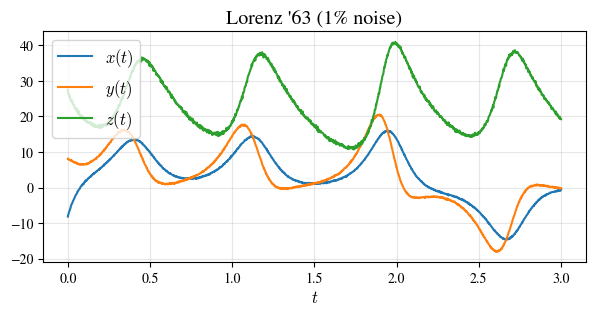

In [16]:
sigma = 10.0
rho = 28.0
beta_param = 8/3
t_np = np.linspace(0, 3, 1501)

def lorenz_rhs(t, z):
  x,y,z0 = z
  return [sigma*(y - x),
          x*(rho - z0) - y,
          x*y - beta_param*z0]

sol = solve_ivp(lorenz_rhs, (t_np[0], t_np[-1]), [-8.0, 8.0, 27.0], t_eval=t_np, rtol=1e-12, atol=1e-12, method='DOP853')

noise = 0.01
t = torch.tensor(t_np, dtype=torch.float64)
lorenz_clean = to_torch_solution(sol)
torch.manual_seed(0)
[x,y,z] = add_noise_to_states(lorenz_clean, noise)

plot_states(t_np, [x,y,z], ['x','y','z'], f"Lorenz '63 ({noise*100:.0f}% noise)")

In [17]:
beta = [[0,0,0],
        [1,0,0],
        [0,1,0],
        [0,0,1],
        [2,0,0],
        [1,1,0],
        [1,0,1],
        [0,2,0],
        [0,1,1],
        [0,0,2]]

[models, odes] = fit_wsindy_system([x,y,z], t, ['x','y','z'], beta, m=[24], p=[12], s=[8], Lambda=1e-2)
check_recovery(models[0], {'(x)': -10.0, '(y)': 10.0}, tol=0.05)
check_recovery(models[1], {'(x)': 28.0, '(y)': -1.0, '(x z)': -1.0}, tol=0.05)
check_recovery(models[2], {'(z)': -8/3, '(x y)': 1.0}, tol=0.05)


  0%|          | 0/1 [00:00<?, ?it/s]


100%|██████████| 1/1 [00:00<00:00, 731.86it/s]

<IPython.core.display.Math object>

HYPER-PARAMETERS
m = [24]
p = [12]
s = [8]
yt = 20.833
yu = 0.289
Aux. scales = [0.259, 0.182]

LIBRARY
Num. query points = 182
Num. terms = 10
cond(G) = 6.963e+02

RESULTS
ODE: x_{t} = - 10.00(x) + 10.00(y)
Nonzero terms = 2
Rel. L2 error = 0.034
R^2 = 0.999
Lambda = 1.000e-02
Loss = 0.202



  0%|          | 0/1 [00:00<?, ?it/s]

...

HYPER-PARAMETERS
m = [24]
p = [12]
s = [8]
yt = 20.833
yu = 0.182
Aux. scales = [0.289, 0.259]

LIBRARY
Num. query points = 182
Num. terms = 10
cond(G) = 6.963e+02

RESULTS
ODE: z_{t} = - 2.66(z) + 1.00(x y)
Nonzero terms = 2
Rel. L2 error = 0.055
R^2 = 0.997
Lambda = 1.000e-02
Loss = 0.204


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Verified: (x) = -9.9986 (true -10), (y) = 9.9966 (true 10)
Verified: (x) = 28.0172 (true 28), (y) = -0.9949 (true -1), (x z) = -1.0006 (true -1)
Verified: (z) = -2.6635 (true -2.66667), (x y) = 0.9995 (true 1)


## **HYPERPARAMETER SWEEPS**

The `hyperparameter_sweep` method probes model recovery over a grid of MSTLS thresholds $\lambda$, test function support radii $m$, and `rescale` on/off (using `s=1`, i.e. the maximum number of query points). Each row of the returned dictionary records the identified model, its nonzero terms and coefficients, and validation metrics (sparsity, MSTLS loss, $R^2$, relative $L^2$ residual, $\kappa(G)$); `csv_path` optionally saves the table, and passing a ground-truth `truth` dictionary adds a maximum relative coefficient error column ($E_\infty$, with dropped terms counted as zero coefficients). By default, `m_values` scales the base model's $m$ by factors $\{0.5, 0.75, 1, 1.25, 1.5\}$ and `Lambdas` uses the same 50-point grid scanned by `MSTLS`.

The heatmaps show sparsity, $R^2$, and $\log_{10}$ coefficient error over the $m$–$\lambda$ plane: a wide plateau at the true model size with $R^2 \approx 1$ marks the stable recovery region.


  0%|          | 0/5 [00:00<?, ?it/s]


  0%|          | 0/1 [00:00<?, ?it/s]


100%|██████████| 1/1 [00:00<00:00, 993.20it/s]


  0%|          | 0/1 [00:00<?, ?it/s]


100%|██████████| 1/1 [00:00<00:00, 996.27it/s]

...


  0%|          | 0/1 [00:00<?, ?it/s]


100%|██████████| 1/1 [00:00<00:00, 1116.99it/s]


  0%|          | 0/1 [00:00<?, ?it/s]


100%|██████████| 1/1 [00:00<00:00, 954.12it/s]


100%|██████████| 5/5 [00:00<00:00, 22.09it/s]

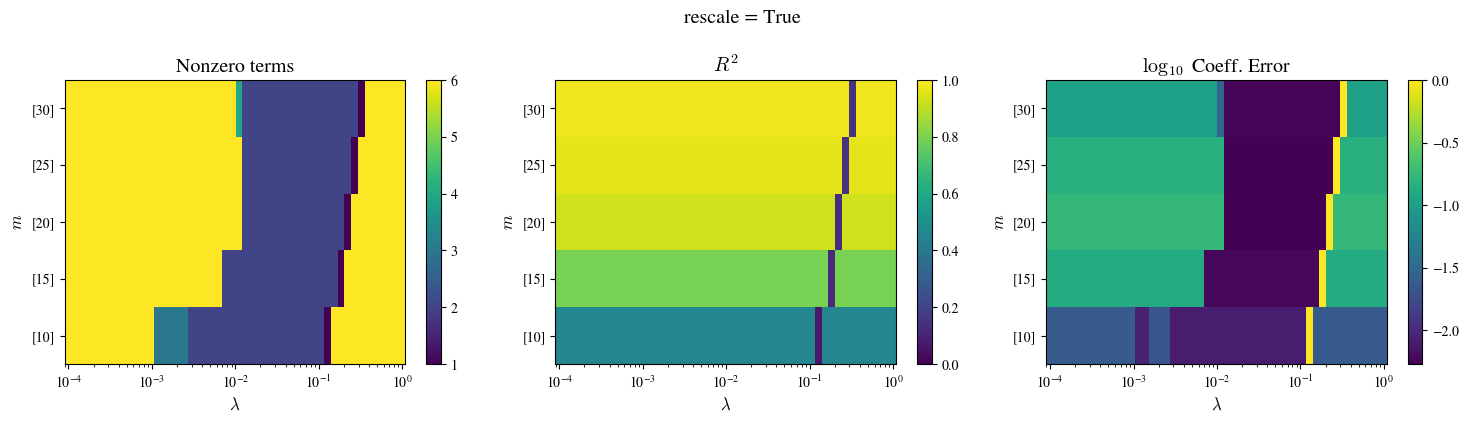

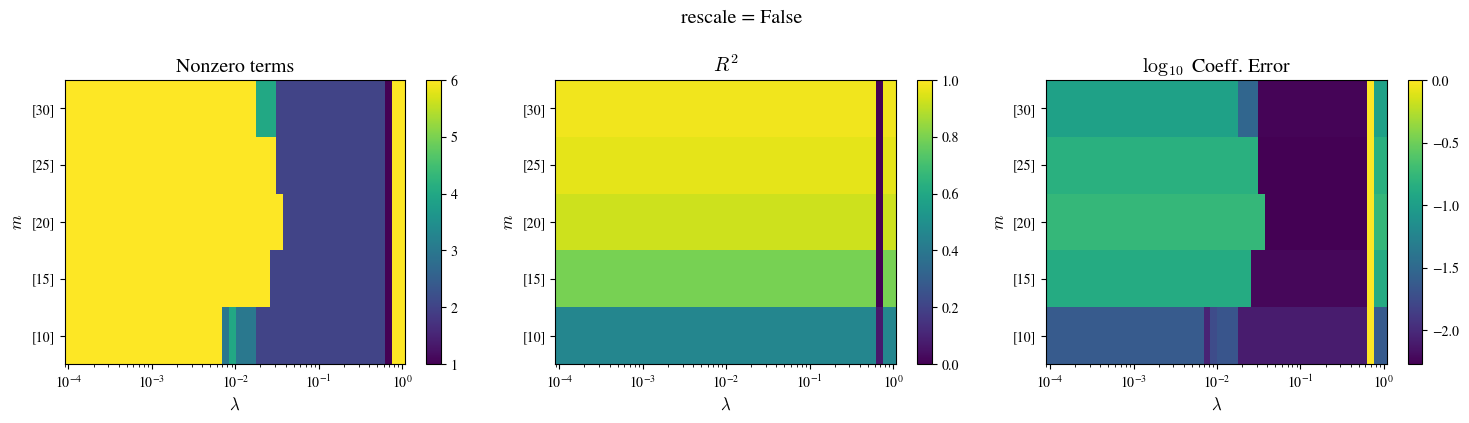

In [20]:
# Lotka-Volterra x-equation at 5% noise, default m and Lambda grids
t = torch.tensor(np.linspace(0, 8, 1001))
torch.manual_seed(0)
[x,y] = add_noise_to_states(lv_clean, 0.05)

beta = [[0,0],
        [1,0],
        [0,1],
        [2,0],
        [1,1],
        [0,2]]

model = WSINDy(x, [[1],[0]], beta, t, V=[y], names=['x','y'], m=[20], p=[10], s=[5],
               verbosity=False, equation_type='ode')
truth = {'(x)': 1.5, '(x y)': -1.0}
results = model.hyperparameter_sweep(lhs_name='x_{t}', truth=truth)

In [21]:
# Most common models across the sweep
from collections import Counter

for model_str,count in Counter(results['model']).most_common(4):
  print(f'{count:3d}/{len(results["model"])} fits: {model_str}')

 96/500 fits: x_{t} = + 1.50(x) - 0.99(x y)
 72/500 fits: x_{t} = + 1.49(x) - 0.99(x y)
 68/500 fits: x_{t} = + 0.56(1) + 1.24(x) - 0.33(y) + 0.04(x^2) - 0.98(x y) + 0.07(y^2)
 66/500 fits: x_{t} = + 0.49(1) + 1.27(x) - 0.30(y) + 0.03(x^2) - 0.97(x y) + 0.06(y^2)



  0%|          | 0/5 [00:00<?, ?it/s]


  0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 5/5 [00:00<00:00, 266.81it/s]


  0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 5/5 [00:00<00:00, 395.91it/s]

...


100%|██████████| 5/5 [00:00<00:00, 331.71it/s]


  0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 5/5 [00:00<00:00, 334.24it/s]


100%|██████████| 5/5 [00:01<00:00,  4.88it/s]


100%|██████████| 5/5 [00:01<00:00,  4.57it/s]

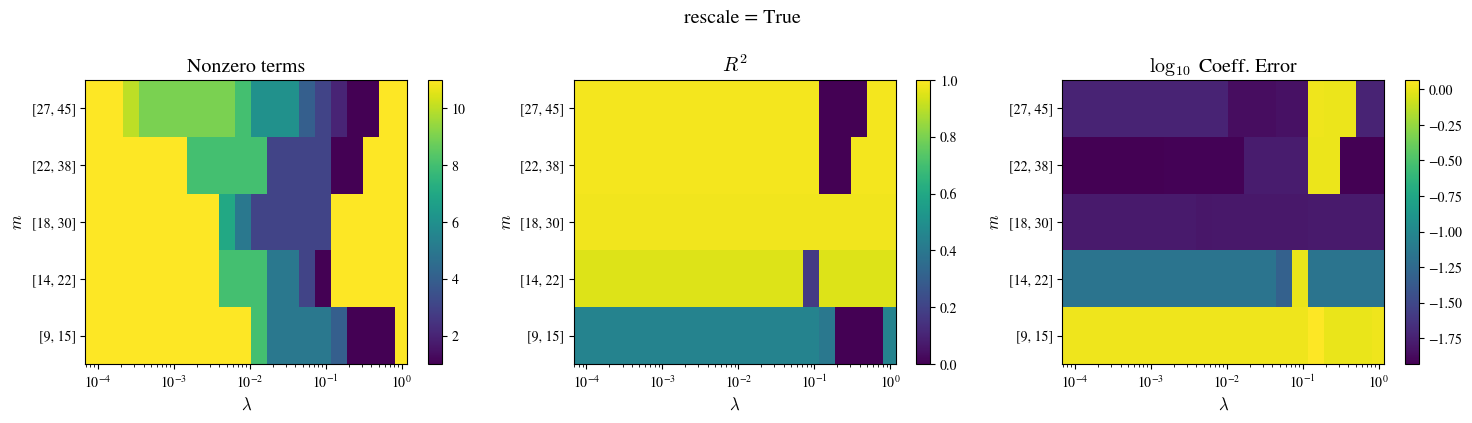

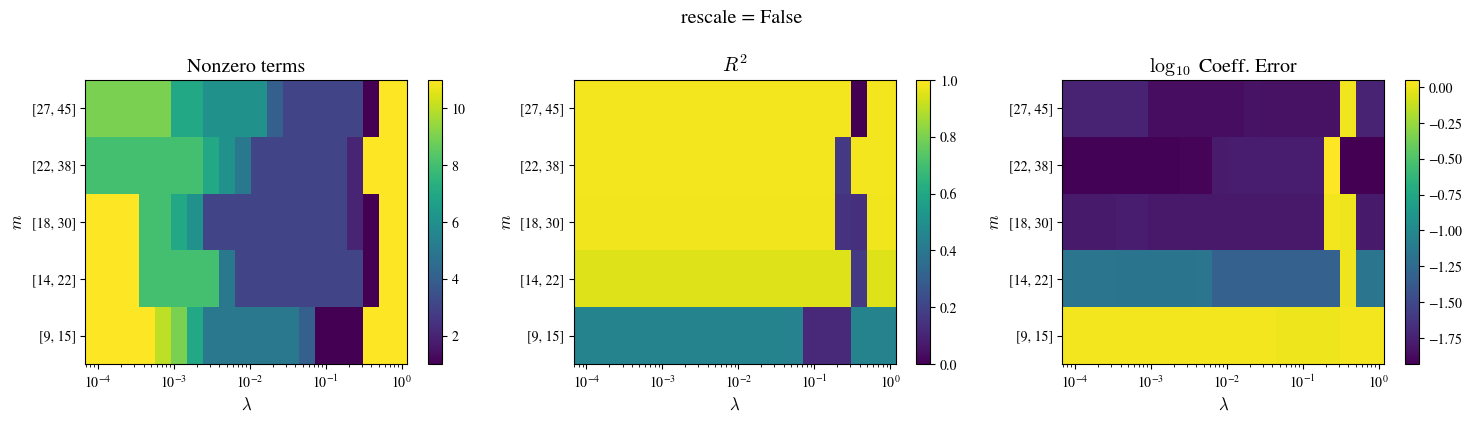

 24/200 fits: u_{t} = - 0.49(u^2)_{x} - 0.99(u)_{xx} - 1.00(u)_{xxxx}
 18/200 fits: u_{t} = + 0.00(1) + 0.12(u) - 0.00(u^2) + 0.01(u)_{x} - 0.27(u^2)_{x} + 0.04(u)_{xx} - 0.00(u^2)_{xx} + 0.01(u)_{xxx} - 0.06(u^2)_{xxx} - 0.09(u)_{xxxx} - 0.00(u^2)_{xxxx}
 18/200 fits: u_{t} = + 0.00(1) + 0.01(u) - 0.00(u^2) + 0.01(u)_{x} - 0.48(u^2)_{x} - 0.93(u)_{xx} - 0.00(u^2)_{xx} + 0.01(u)_{xxx} - 0.01(u^2)_{xxx} - 0.94(u)_{xxxx} - 0.00(u^2)_{xxxx}
 18/200 fits: u_{t} = + 0.00(1) + 0.00(u) - 0.00(u^2) + 0.00(u)_{x} - 0.49(u^2)_{x} - 0.99(u)_{xx} - 0.00(u^2)_{xx} + 0.01(u)_{xxx} + 0.00(u^2)_{xxx} - 1.00(u)_{xxxx} + 0.00(u^2)_{xxxx}


In [22]:
# Kuramoto Sivashinsky at 20% noise, reduced Lambda grid, results saved to CSV
U = torch.tensor(np.loadtxt('../Datasets/KS.txt', delimiter=','))
torch.manual_seed(0)
U = add_noise(U, 0.2).view(256, -1)
x = torch.linspace(0, 32*np.pi, 256)
t = torch.linspace(0, 150, 301)

alpha = [[0,1],
         [0,0],
         [1,0],
         [2,0],
         [3,0],
         [4,0]]

beta = [[0],
        [1],
        [2]]

model = WSINDy(U, alpha, beta, [x,t], m=[18,30], verbosity=False, equation_type='pde')
truth = {'(u^2)_{x}': -0.5, '(u)_{xx}': -1.0, '(u)_{xxxx}': -1.0}
Lambdas = 10**((4/19)*torch.arange(0,20)-4)
results = model.hyperparameter_sweep(lhs_name='u_{t}', Lambdas=Lambdas, truth=truth, csv_path='ks_sweep.csv')

for model_str,count in Counter(results['model']).most_common(4):
  print(f'{count:3d}/{len(results["model"])} fits: {model_str}')